In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
#print directory content of active directory

#view the data on ArcGIS online here: https://governmentofbc.maps.arcgis.com/home/item.html?id=ce7fd87476b54100a3b158c9dae7e9b7

# Base URL for the ArcGIS REST API
base_url = "https://delivery.maps.gov.bc.ca/arcgis/rest/services/whse/bcgw_pub_whse_cadastre/MapServer"
layer_id = 1

# Full URL for the query operation
query_url = f"{base_url}/{layer_id}/query"

#set values as true or false based on assessment roll availability
munis = {
    'Victoria, The Corporation of the City of': True,
    'Saanich, The Corporation of the District of': False,
    'Esquimalt, Corporation of the Township of': True,
    'Oak Bay, The Corporation of the District of': False,
    'View Royal, Town of': False
}

where_clause = "MUNICIPALITY IN ("
for muni in munis.keys():
    if munis[muni] == True:
        where_clause += f"'{muni}', "
where_clause = where_clause[:-2] + ")"

print(where_clause)

# Query parameters
params = {
    "where": where_clause,  # Victoria only
    "outFields": "*",  # Retrieve all fields
    "f": "geojson",  # Output format
    "resultRecordCount": 1000,  # Max records per request
}

# Initialize variables for pagination
result_offset = 0
all_features = []

while True:
    print("new page!")
    # Update the resultOffset parameter for pagination
    params["resultOffset"] = result_offset

    # Send the query request
    response = requests.get(query_url, params=params)

    # Check if the request was successful
    if response.status_code != 200:
        print(f"Failed to fetch data. HTTP status code: {response.status_code}")
        print(response.text)
        break

    # Parse the GeoJSON response
    geojson_data = response.json()

    # Extract features
    features = geojson_data.get("features", [])
    all_features.extend(features)

    # Check if there are more records to fetch
    if len(features) < params["resultRecordCount"]:
        # If fewer records are returned, we’ve fetched everything
        break

    # Increment the offset for the next batch
    result_offset += params["resultRecordCount"]

# Load all features into a GeoDataFrame
if all_features:
    gdf = gpd.GeoDataFrame.from_features(all_features)
    
    gdf = gdf.set_crs(epsg=102190).to_crs(epsg=26910) #from  BC Albers to UTM Zone 10N

    #download to parcels/raw_download.geojson
    gdf.to_file("parcels/raw_download.geojson", driver='GeoJSON')
    print("All data retrieved")

else:
    print("No data retrieved.")


MUNICIPALITY IN ('Victoria, The Corporation of the City of', 'Esquimalt, Corporation of the Township of')
new page!
new page!
new page!
new page!
new page!


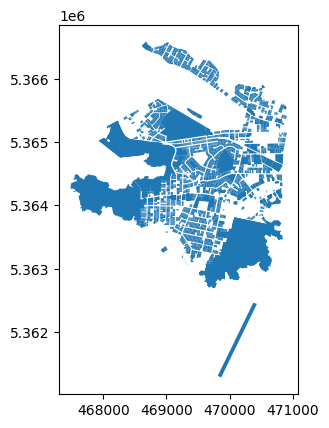

In [4]:
parcels = gpd.read_file("parcels/raw_download.geojson")

parcels.plot()
plt.show()